<a href="https://colab.research.google.com/github/Baasmaala/road-safety-explorer/blob/omar/notebooks/02_pca_anomaly_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# SETUP CELL — run this first every session
# ============================================================
import os, sys, subprocess

REPO_URL  = "https://github.com/Baasmaala/road-safety-explorer.git"
REPO_NAME = "road-safety-explorer"
BRANCH    = "omar"

# Clone if not already cloned, otherwise pull latest
if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_NAME}...")
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
else:
    print(f"Repo already cloned — pulling latest from {BRANCH}...")
    subprocess.run(["git", "-C", REPO_NAME, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_NAME, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_NAME, "pull", "origin", BRANCH], check=True)

# Move into the repo so all paths like data/raw/... just work
os.chdir(REPO_NAME)
print(f"\n Working directory: {os.getcwd()}")
print(f" On branch: {BRANCH}")
print(f" Files available:")
subprocess.run(["ls", "-la", "data/raw/"])

Repo already cloned — pulling latest from omar...

 Working directory: /content/road-safety-explorer
 On branch: omar
 Files available:


CompletedProcess(args=['ls', '-la', 'data/raw/'], returncode=0)

# Notebook 02 — PCA and Anomaly Detection

This notebook implements the PCA and country-level anomaly detection part of the Global Road Safety Explorer project.

The input of this notebook is the cleaned country-level feature matrix produced by Notebook 01.  
The main goals are:

1. Standardize the numeric road-safety indicators.
2. Apply PCA to reduce the high-dimensional feature space into two dimensions.
3. Detect unusual countries using Isolation Forest.
4. Save the outputs for the Streamlit application.

The generated files are:

- `country_pca.csv`
- `country_anomalies.csv`

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

## 1. Load the processed data

This notebook does not clean the raw WHO dataset again.  
Instead, it starts from the processed files created in Notebook 01:

- `country_features.csv`: cleaned country-level numeric features
- `country_clusters.csv`: cluster labels produced by the clustering step

Using the processed files keeps the workflow organized and avoids repeating the same preprocessing steps.

In [3]:

current_dir = Path.cwd()

if (current_dir / "data").exists():
    project_root = current_dir
elif (current_dir.parent / "data").exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError("Could not find the project root folder containing the data directory.")

processed_dir = project_root / "data" / "processed"

features_path = processed_dir / "country_features.csv"
clusters_path = processed_dir / "country_clusters.csv"

print("Project root:", project_root)
print("Features file exists:", features_path.exists())
print("Clusters file exists:", clusters_path.exists())

Project root: /content/road-safety-explorer
Features file exists: True
Clusters file exists: True


In [4]:
features_df = pd.read_csv(features_path)
clusters_df = pd.read_csv(clusters_path)

print("country_features shape:", features_df.shape)
print("country_clusters shape:", clusters_df.shape)

display(features_df.head())
display(clusters_df.head())

country_features shape: (171, 31)
country_clusters shape: (171, 6)


,ISO_3 country name,Country name,Income group,WHO Region,Year reported fatalities,Reported fatalities gender distribution (% Males),Reported fatalities gender distribution (%Females),Reported fatalities user distribution (% powered light vehicles),Reported fatalities user distribution (% powered 2/ wheelers),Reported fatalities user distribution (% pedestrian),...,Year total registered vehicles,Year by fatality reduction target,Adherence to one or more of the 7 UN road safety conventions,Legislation setting appropriate urban speed limits for passenger cars and motorcycles,Legislation on drink driving,Legislation requiring adult motorcycle riders to wear a helmet properly fastened that meets appropriate standards,Legislation on the use of seat belts for all motor vehicle occupants (UNVTI 8a),Legislation requiring the use of child safety restraint systems that meet appropriate standards,2010 WHO-estimated rate per 100 000 population (update),2016 WHO-estimated rate per 100 000 population (update)
0,ALB,Albania,Upper middle income,European Region,2021,78.7,21.30,57.4,5.6,19.3,...,2021.0,2030.0,6,3,2,2,3,2,13.3,12.8
1,DZA,Algeria,Lower middle income,African Region,2021,79.0,20.74,0.0,0.0,25.0,...,2021.0,2030.0,1,3,3,2,3,1,22.4,21.2
2,ATG,Antigua and Barbuda,High income,Region of the Americas,2021,86.0,14.00,57.0,0.0,43.0,...,2021.0,2030.0,0,2,1,1,1,1,5.8,8.8
3,ARG,Argentina,Upper middle income,Region of the Americas,2021,79.0,20.00,31.6,46.3,10.9,...,2021.0,2030.0,1,1,2,3,3,3,12.8,13.2
4,ARM,Armenia,Upper middle income,European Region,2021,75.5,24.50,68.2,0.0,31.8,...,2021.0,2030.0,4,1,2,2,3,1,16.1,17.5


,ISO_3 country name,Country name,Income group,WHO Region,Cluster,Cluster_name
0,ALB,Albania,Upper middle income,European Region,1,Rich-country car culture
1,DZA,Algeria,Lower middle income,African Region,0,Developing-country road profile
2,ATG,Antigua and Barbuda,High income,Region of the Americas,2,Low-motorization mixed
3,ARG,Argentina,Upper middle income,Region of the Americas,1,Rich-country car culture
4,ARM,Armenia,Upper middle income,European Region,0,Developing-country road profile


## 2. Select numeric features

PCA and Isolation Forest cannot be applied directly to text columns such as country name, region, or income group.

Therefore, we separate:

- identifier / descriptive columns: used later for interpretation
- numeric feature columns: used for PCA and anomaly detection

The numeric columns represent the road-safety profile of each country

In [5]:
print("Columns in country_features.csv:")
for col in features_df.columns:
    print("-", col)

Columns in country_features.csv:
- ISO_3 country name
- Country name
- Income group
- WHO Region
- Year reported fatalities
- Reported fatalities gender distribution  (% Males)
- Reported fatalities gender distribution  (%Females)
- Reported fatalities user distribution  (% powered light vehicles)
- Reported fatalities user distribution  (% powered 2/ wheelers)
- Reported fatalities user distribution  (% pedestrian)
- Reported fatalities user distribution  (% cyclist)
- Reported fatalities user distribution  (% other)
- WHO-estimated rate per 100 000 population
- Total paved kilometres (year)
- Year total paved kilometres
- Total registered vehicles 
- Total registered vehicles rate per 100 000 pop
- Cars and 4-wheeled light vehicles 
- Powered 2- and 3-wheelers 
- Heavy trucks 
- Buses 
- Year total registered vehicles
- Year by fatality reduction target 
- Adherence to one or more of the 7 UN road safety conventions
- Legislation setting appropriate urban speed limits for passenger c

In [6]:
# Possible identifier / descriptive columns
# The code is flexible because column names may slightly differ between files

possible_id_cols = [
    "ISO_3 country name",
    "ISO_3",
    "ISO3",
    "Code",
    "country_code",
    "Country code"
]

possible_country_cols = [
    "Country name",
    "Country",
    "Entity",
    "country",
    "Country_Name"
]

possible_metadata_cols = [
    "Income group",
    "WHO Region",
    "Region",
    "World Bank income group",
    "Population"
]

id_cols = [col for col in possible_id_cols if col in features_df.columns]
country_cols = [col for col in possible_country_cols if col in features_df.columns]
metadata_cols = [col for col in possible_metadata_cols if col in features_df.columns]

# Keep useful descriptive columns for the output
output_info_cols = []
for col in id_cols + country_cols + metadata_cols:
    if col not in output_info_cols:
        output_info_cols.append(col)

# Select numeric columns only
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()

# Remove metadata-like numeric columns if they exist
# These columns describe data/reporting years, not direct road-safety indicators
# Excluding them makes PCA and anomaly detection focus more on actual road-safety patterns

exclude_from_model = [
    "Cluster",
    "cluster",
    "Population",
    "Year reported fatalities",
    "Year total paved kilometres",
    "Year total registered vehicles",
    "Year by fatality reduction target "
]

numeric_cols = [
    col for col in numeric_cols
    if col not in exclude_from_model
    and col.strip() not in [x.strip() for x in exclude_from_model]
]

print("Identifier columns:", id_cols)
print("Country columns:", country_cols)
print("Metadata columns:", metadata_cols)
print("Number of numeric features used:", len(numeric_cols))

print("\nNumeric features used for PCA and anomaly detection:")
for col in numeric_cols:
    print("-", col)

Identifier columns: ['ISO_3 country name']
Country columns: ['Country name']
Metadata columns: ['Income group', 'WHO Region']
Number of numeric features used: 23

Numeric features used for PCA and anomaly detection:
- Reported fatalities gender distribution  (% Males)
- Reported fatalities gender distribution  (%Females)
- Reported fatalities user distribution  (% powered light vehicles)
- Reported fatalities user distribution  (% powered 2/ wheelers)
- Reported fatalities user distribution  (% pedestrian)
- Reported fatalities user distribution  (% cyclist)
- Reported fatalities user distribution  (% other)
- WHO-estimated rate per 100 000 population
- Total paved kilometres (year)
- Total registered vehicles 
- Total registered vehicles rate per 100 000 pop
- Cars and 4-wheeled light vehicles 
- Powered 2- and 3-wheelers 
- Heavy trucks 
- Buses 
- Adherence to one or more of the 7 UN road safety conventions
- Legislation setting appropriate urban speed limits for passenger cars and 

In [7]:
if len(numeric_cols) < 3:
    raise ValueError("At least 3 numeric columns are needed for meaningful PCA and anomaly detection.")

X = features_df[numeric_cols].copy()

# fill any remaining missing numeric values with the median
missing_before = X.isna().sum().sum()

if missing_before > 0:
    X = X.fillna(X.median(numeric_only=True))

missing_after = X.isna().sum().sum()

print("Missing values before:", missing_before)
print("Missing values after:", missing_after)
print("Final feature matrix shape:", X.shape)

Missing values before: 0
Missing values after: 0
Final feature matrix shape: (171, 23)


## 3. Standardization

The numeric indicators may use different scales.  
For example, some indicators may be percentages, while others may be counts or rates.

Before applying PCA and Isolation Forest, all numeric features are standardized using `StandardScaler`.

This transforms each feature to have approximately:

- mean = 0
- standard deviation = 1

This prevents features with larger numeric ranges from dominating the analysis.

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)
print("Mean after scaling, approximately:", round(X_scaled.mean(), 4))
print("Standard deviation after scaling, approximately:", round(X_scaled.std(), 4))

Scaled feature matrix shape: (171, 23)
Mean after scaling, approximately: 0.0
Standard deviation after scaling, approximately: 1.0


## 4. Principal Component Analysis PCA

PCA is used here for visualization and interpretation.

The original dataset contains many road-safety indicators, which makes it difficult to visually compare countries.  
PCA reduces the high-dimensional feature space into two main components:

- PC1
- PC2

Each country becomes one point on a 2D landscape.

Note: PCA is not used here to create clusters because the clusters were created earlier in Notebook 01  
Here, PCA is used to visualize how countries relate to each other.

In [9]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

pca_df = features_df[output_info_cols].copy()

pca_df["PC1"] = pca_components[:, 0]
pca_df["PC2"] = pca_components[:, 1]

explained_variance = pca.explained_variance_ratio_
total_explained = explained_variance.sum()

print("PCA explained variance:")
print("PC1:", round(explained_variance[0] * 100, 2), "%")
print("PC2:", round(explained_variance[1] * 100, 2), "%")
print("Total:", round(total_explained * 100, 2), "%")

display(pca_df.head())

PCA explained variance:
PC1: 23.83 %
PC2: 15.43 %
Total: 39.26 %


,ISO_3 country name,Country name,Income group,WHO Region,PC1,PC2
0,ALB,Albania,Upper middle income,European Region,0.604186,-1.902971
1,DZA,Algeria,Lower middle income,African Region,-0.005619,2.515615
2,ATG,Antigua and Barbuda,High income,Region of the Americas,-2.917392,-3.038031
3,ARG,Argentina,Upper middle income,Region of the Americas,2.654829,1.552066
4,ARM,Armenia,Upper middle income,European Region,-0.264328,-0.399038


### PCA interpretation

The explained variance tells us how much of the original information is captured by the two PCA components.

A higher total explained variance means the 2D plot represents more of the original feature structure.  
However, even if the total is not very high, PCA is still useful as a visual approximation of how countries are positioned relative to each other.

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=numeric_cols
)

print("Top features contributing to PC1:")
display(loadings["PC1_loading"].abs().sort_values(ascending=False).head(10))

print("Top features contributing to PC2:")
display(loadings["PC2_loading"].abs().sort_values(ascending=False).head(10))

Top features contributing to PC1:


,PC1_loading
Total registered vehicles rate per 100 000 pop,0.313375
Legislation requiring the use of child safety restraint systems that meet appropriate standards,0.305257
Cars and 4-wheeled light vehicles,0.275803
Total registered vehicles,0.264778
Adherence to one or more of the 7 UN road safety conventions,0.264624
2016 WHO-estimated rate per 100 000 population (update),0.259069
WHO-estimated rate per 100 000 population,0.251041
Heavy trucks,0.248051
2010 WHO-estimated rate per 100 000 population (update),0.243577
Legislation on drink driving,0.237355


Top features contributing to PC2:


,PC2_loading
Buses,0.353125
Heavy trucks,0.347203
Total registered vehicles,0.299072
2016 WHO-estimated rate per 100 000 population (update),0.296671
2010 WHO-estimated rate per 100 000 population (update),0.295881
WHO-estimated rate per 100 000 population,0.287693
Cars and 4-wheeled light vehicles,0.281447
Powered 2- and 3-wheelers,0.279194
Reported fatalities user distribution (% powered light vehicles),0.227198
Total paved kilometres (year),0.199841


## 5. Merge PCA output with cluster labels

The clustering step was already completed in Notebook 01.  
Here we merge the PCA coordinates with the cluster labels so that the Streamlit app can display:

- each country as a point
- the PCA position of the country
- the cluster assignment of the country

In [11]:
print("Columns in country_clusters.csv:")
for col in clusters_df.columns:
    print("-", col)

Columns in country_clusters.csv:
- ISO_3 country name
- Country name
- Income group
- WHO Region
- Cluster
- Cluster_name


In [12]:
# try to find a common country code column between the two files

common_cols = [col for col in pca_df.columns if col in clusters_df.columns]

preferred_merge_cols = [
    "ISO_3 country name",
    "ISO_3",
    "ISO3",
    "Code",
    "country_code",
    "Country code",
    "Country name",
    "Country",
    "Entity"
]

merge_col = None

for col in preferred_merge_cols:
    if col in common_cols:
        merge_col = col
        break

if merge_col is None:
    raise ValueError("No common country identifier column found between PCA data and cluster data.")

print("Merging using column:", merge_col)

cluster_label_candidates = ["Cluster", "cluster", "cluster_label", "Cluster Label"]
cluster_col = None

for col in cluster_label_candidates:
    if col in clusters_df.columns:
        cluster_col = col
        break

if cluster_col is None:
    raise ValueError("No cluster label column found in country_clusters.csv.")

# Merge the numeric cluster label and, if available, the descriptive cluster name.
extra_cluster_cols = [cluster_col]

for optional_col in ["Cluster_name", "cluster_name", "Cluster Name"]:
    if optional_col in clusters_df.columns and optional_col not in extra_cluster_cols:
        extra_cluster_cols.append(optional_col)

cluster_merge_df = clusters_df[[merge_col] + extra_cluster_cols].copy()

pca_df = pca_df.merge(
    cluster_merge_df,
    on=merge_col,
    how="left"
)

if cluster_col != "Cluster":
    pca_df = pca_df.rename(columns={cluster_col: "Cluster"})

print("Missing cluster labels after merge:", pca_df["Cluster"].isna().sum())

if "Cluster_name" in pca_df.columns:
    print("Cluster_name column was merged successfully.")

display(pca_df.head())

Merging using column: ISO_3 country name
Missing cluster labels after merge: 0
Cluster_name column was merged successfully.


,ISO_3 country name,Country name,Income group,WHO Region,PC1,PC2,Cluster,Cluster_name
0,ALB,Albania,Upper middle income,European Region,0.604186,-1.902971,1,Rich-country car culture
1,DZA,Algeria,Lower middle income,African Region,-0.005619,2.515615,0,Developing-country road profile
2,ATG,Antigua and Barbuda,High income,Region of the Americas,-2.917392,-3.038031,2,Low-motorization mixed
3,ARG,Argentina,Upper middle income,Region of the Americas,2.654829,1.552066,1,Rich-country car culture
4,ARM,Armenia,Upper middle income,European Region,-0.264328,-0.399038,0,Developing-country road profile


## 6. Country-level anomaly detection

Anomaly detection is used to identify countries with unusual road-safety profiles.

Isolation Forest is used because it works well for detecting outliers in multidimensional numeric data.

The model gives each country an anomaly score.  
Countries with the most unusual feature patterns are flagged as anomalies.

In the output:

- `is_anomaly = True` means the country is considered unusual compared with the global dataset.
- `anomaly_score` shows how unusual the country is. Higher values mean stronger anomaly behavior.

In [13]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly_labels = isolation_forest.fit_predict(X_scaled)

# decision_function gives higher values for normal points.
# we multiply by -1 so that higher anomaly_score means more unusual.
anomaly_scores = -isolation_forest.decision_function(X_scaled)

pca_df["anomaly_label"] = anomaly_labels
pca_df["is_anomaly"] = pca_df["anomaly_label"] == -1
pca_df["anomaly_score"] = anomaly_scores

print("Number of anomaly countries:", pca_df["is_anomaly"].sum())
print("Percentage of anomaly countries:", round(pca_df["is_anomaly"].mean() * 100, 2), "%")

display(pca_df.sort_values("anomaly_score", ascending=False).head(10))

Number of anomaly countries: 9
Percentage of anomaly countries: 5.26 %


,ISO_3 country name,Country name,Income group,WHO Region,PC1,PC2,Cluster,Cluster_name,anomaly_label,is_anomaly,anomaly_score
114,NIU,Niue,NaN,Western Pacific Region,-0.970468,-1.153269,2,Low-motorization mixed,-1,True,0.073481
36,COK,Cook Islands,NaN,Western Pacific Region,-4.723046,-3.746122,2,Low-motorization mixed,-1,True,0.047525
41,CYP,Cyprus,High income,European Region,-2.218471,-6.861774,2,Low-motorization mixed,-1,True,0.027839
153,THA,Thailand,Upper middle income,South-East Asia Region,1.038490,5.364583,0,Developing-country road profile,-1,True,0.023724
58,GEO,Georgia,Upper middle income,European Region,-5.222632,-5.792424,2,Low-motorization mixed,-1,True,0.022464
163,USA,United States of America,High income,Region of the Americas,3.354524,3.074505,1,Rich-country car culture,-1,True,0.018452
21,VGB,British Virgin Islands,High income,Region of the Americas,-1.629618,-0.533546,2,Low-motorization mixed,-1,True,0.004264
101,MEX,Mexico,Upper middle income,Region of the Americas,2.233564,3.470021,0,Developing-country road profile,-1,True,0.003356
96,MDV,Maldives,Upper middle income,South-East Asia Region,-0.456679,-1.843786,2,Low-motorization mixed,-1,True,0.000052
71,IDN,Indonesia,Lower middle income,South-East Asia Region,1.953296,3.831682,0,Developing-country road profile,1,False,-0.000052


### Why contamination = 0.05?

The `contamination` value controls the expected proportion of anomalies.

Here, `contamination = 0.05` means that around 5% of countries are expected to be flagged as unusual.

This is a reasonable conservative choice because the goal is not to label many countries as abnormal, but to highlight the strongest outliers for further interpretation.

In [14]:
# find Palestine using either ISO code PSE or country name.

palestine_mask = pd.Series(False, index=pca_df.index)

for col in pca_df.columns:
    if pca_df[col].dtype == "object":
        palestine_mask = palestine_mask | pca_df[col].astype(str).str.contains(
            "Palestine|PSE|Palestinian",
            case=False,
            na=False
        )

palestine_row = pca_df[palestine_mask]

print("Palestine rows found:", len(palestine_row))
display(palestine_row)

Palestine rows found: 1


,ISO_3 country name,Country name,Income group,WHO Region,PC1,PC2,Cluster,Cluster_name,anomaly_label,is_anomaly,anomaly_score
117,PSE,Palestine,Lower middle income,Eastern Mediterranean Region,-0.27431,-2.633081,2,Low-motorization mixed,1,False,-0.045452


## 7. PCA visualization

The plot below shows the country landscape after PCA.

- Each point represents a country.
- The x-axis is PC1.
- The y-axis is PC2.
- Colors represent the cluster labels from Notebook 01.
- Red circles highlight anomaly countries.
- The star marker highlights Palestine.

This visualization will later be used as the basis for the Streamlit PCA landscape page.

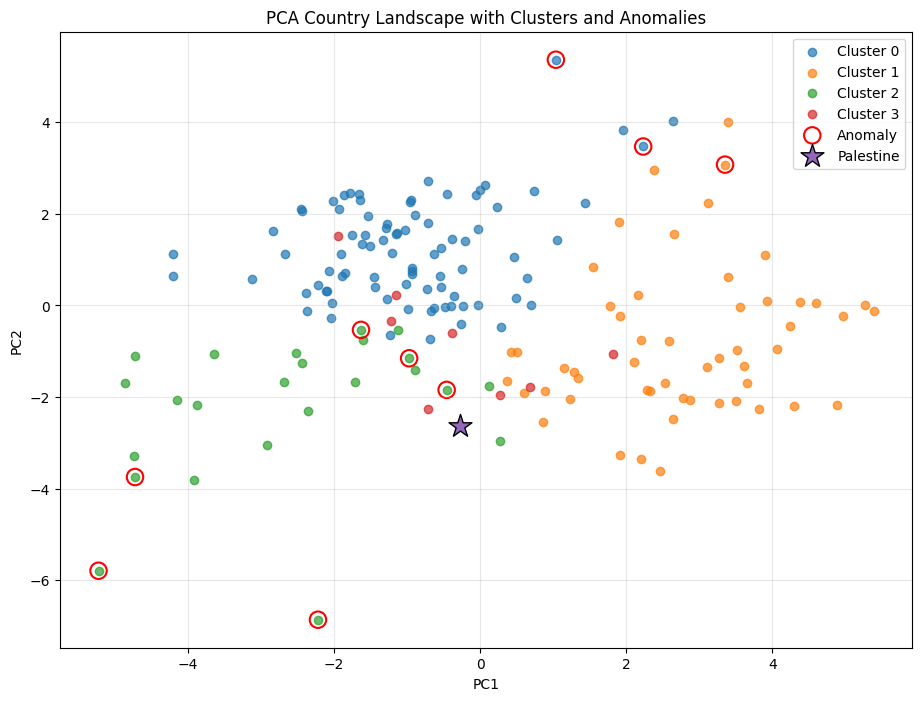

In [15]:
plt.figure(figsize=(11, 8))

# Plot countries by cluster.
for cluster in sorted(pca_df["Cluster"].dropna().unique()):
    cluster_data = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {int(cluster)}" if float(cluster).is_integer() else f"Cluster {cluster}",
        alpha=0.7
    )

# Highlight anomalies.
anomalies = pca_df[pca_df["is_anomaly"]]

plt.scatter(
    anomalies["PC1"],
    anomalies["PC2"],
    facecolors="none",
    edgecolors="red",
    s=140,
    linewidths=1.5,
    label="Anomaly"
)

# Highlight Palestine.
if len(palestine_row) > 0:
    plt.scatter(
        palestine_row["PC1"],
        palestine_row["PC2"],
        marker="*",
        s=300,
        edgecolors="black",
        linewidths=1,
        label="Palestine"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Country Landscape with Clusters and Anomalies")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Inspect anomaly countries

The table below shows the countries with the highest anomaly scores.

These countries have road-safety indicator patterns that differ strongly from the general structure of the dataset.

An anomaly does not automatically mean the country is bad or unsafe.  
It only means that its profile is unusual compared with other countries in the dataset.

In [16]:
top_anomalies = pca_df[pca_df["is_anomaly"]].sort_values(
    "anomaly_score",
    ascending=False
)

display(top_anomalies)

,ISO_3 country name,Country name,Income group,WHO Region,PC1,PC2,Cluster,Cluster_name,anomaly_label,is_anomaly,anomaly_score
114,NIU,Niue,NaN,Western Pacific Region,-0.970468,-1.153269,2,Low-motorization mixed,-1,True,0.073481
36,COK,Cook Islands,NaN,Western Pacific Region,-4.723046,-3.746122,2,Low-motorization mixed,-1,True,0.047525
41,CYP,Cyprus,High income,European Region,-2.218471,-6.861774,2,Low-motorization mixed,-1,True,0.027839
153,THA,Thailand,Upper middle income,South-East Asia Region,1.038490,5.364583,0,Developing-country road profile,-1,True,0.023724
58,GEO,Georgia,Upper middle income,European Region,-5.222632,-5.792424,2,Low-motorization mixed,-1,True,0.022464
163,USA,United States of America,High income,Region of the Americas,3.354524,3.074505,1,Rich-country car culture,-1,True,0.018452
21,VGB,British Virgin Islands,High income,Region of the Americas,-1.629618,-0.533546,2,Low-motorization mixed,-1,True,0.004264
101,MEX,Mexico,Upper middle income,Region of the Americas,2.233564,3.470021,0,Developing-country road profile,-1,True,0.003356
96,MDV,Maldives,Upper middle income,South-East Asia Region,-0.456679,-1.843786,2,Low-motorization mixed,-1,True,0.000052


## 9. Save outputs

The final step is to save the PCA and anomaly detection outputs.

These files will be used later by the Streamlit application:

- `country_pca.csv`: contains PCA coordinates, cluster labels, and anomaly information for all countries.
- `country_anomalies.csv`: contains only the countries flagged as anomalies.

In [17]:
country_pca_path = processed_dir / "country_pca.csv"
country_anomalies_path = processed_dir / "country_anomalies.csv"

pca_df.to_csv(country_pca_path, index=False)

anomalies_df = pca_df[pca_df["is_anomaly"]].sort_values(
    "anomaly_score",
    ascending=False
)

anomalies_df.to_csv(country_anomalies_path, index=False)

print("Saved PCA output to:", country_pca_path)
print("country_pca.csv shape:", pca_df.shape)

print("\nSaved anomaly output to:", country_anomalies_path)
print("country_anomalies.csv shape:", anomalies_df.shape)

Saved PCA output to: /content/road-safety-explorer/data/processed/country_pca.csv
country_pca.csv shape: (171, 11)

Saved anomaly output to: /content/road-safety-explorer/data/processed/country_anomalies.csv
country_anomalies.csv shape: (9, 11)


In [18]:
saved_pca = pd.read_csv(country_pca_path)
saved_anomalies = pd.read_csv(country_anomalies_path)

print("Reloaded country_pca.csv:", saved_pca.shape)
print("Reloaded country_anomalies.csv:", saved_anomalies.shape)

display(saved_pca.head())
display(saved_anomalies.head())

Reloaded country_pca.csv: (171, 11)
Reloaded country_anomalies.csv: (9, 11)


,ISO_3 country name,Country name,Income group,WHO Region,PC1,PC2,Cluster,Cluster_name,anomaly_label,is_anomaly,anomaly_score
0,ALB,Albania,Upper middle income,European Region,0.604186,-1.902971,1,Rich-country car culture,1,False,-0.114957
1,DZA,Algeria,Lower middle income,African Region,-0.005619,2.515615,0,Developing-country road profile,1,False,-0.075317
2,ATG,Antigua and Barbuda,High income,Region of the Americas,-2.917392,-3.038031,2,Low-motorization mixed,1,False,-0.007023
3,ARG,Argentina,Upper middle income,Region of the Americas,2.654829,1.552066,1,Rich-country car culture,1,False,-0.090170
4,ARM,Armenia,Upper middle income,European Region,-0.264328,-0.399038,0,Developing-country road profile,1,False,-0.151330


,ISO_3 country name,Country name,Income group,WHO Region,PC1,PC2,Cluster,Cluster_name,anomaly_label,is_anomaly,anomaly_score
0,NIU,Niue,NaN,Western Pacific Region,-0.970468,-1.153269,2,Low-motorization mixed,-1,True,0.073481
1,COK,Cook Islands,NaN,Western Pacific Region,-4.723046,-3.746122,2,Low-motorization mixed,-1,True,0.047525
2,CYP,Cyprus,High income,European Region,-2.218471,-6.861774,2,Low-motorization mixed,-1,True,0.027839
3,THA,Thailand,Upper middle income,South-East Asia Region,1.038490,5.364583,0,Developing-country road profile,-1,True,0.023724
4,GEO,Georgia,Upper middle income,European Region,-5.222632,-5.792424,2,Low-motorization mixed,-1,True,0.022464


## Conclusion

This notebook completed the PCA and country-level anomaly detection stage of the project.

The numeric road-safety indicators were standardized before analysis.  
PCA reduced the high-dimensional country feature matrix into two dimensions, allowing countries to be visualized on a 2D landscape.  
Isolation Forest was then used to identify countries with unusual road-safety profiles.

The outputs were saved as:

- `country_pca.csv`
- `country_anomalies.csv`

These files can be used later in the Streamlit application, especially in the Cluster Landscape / PCA page.